In [13]:
import numpy as np
import pandas as pd
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cpu


In [ ]:
df = pd.read_csv("cellula toxic data.csv") 


print(df.shape)
df.head()

(3000, 3)


,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [5]:
df.isnull().sum()

query                 0
image descriptions    0
Toxic Category        0
dtype: int64

In [10]:
print(df['query'][0])
print(df['image descriptions'][0])
print(df['Toxic Category'][0])

What is the right way to handle a severe head injury?
A child playing in a sunny meadow.
Safe


--- Class Distribution ---
                           Count  Percentage (%)
Toxic Category                                  
Safe                         995           33.17
Violent Crimes               792           26.40
Non-Violent Crimes           301           10.03
unsafe                       274            9.13
Unknown S-Type               196            6.53
Sex-Related Crimes           115            3.83
Suicide & Self-Harm          114            3.80
Elections                    110            3.67
Child Sexual Exploitation    103            3.43


C:\Users\mocam\AppData\Local\Temp\ipykernel_30924\3413094054.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.values, y=target_counts.index, palette="viridis")


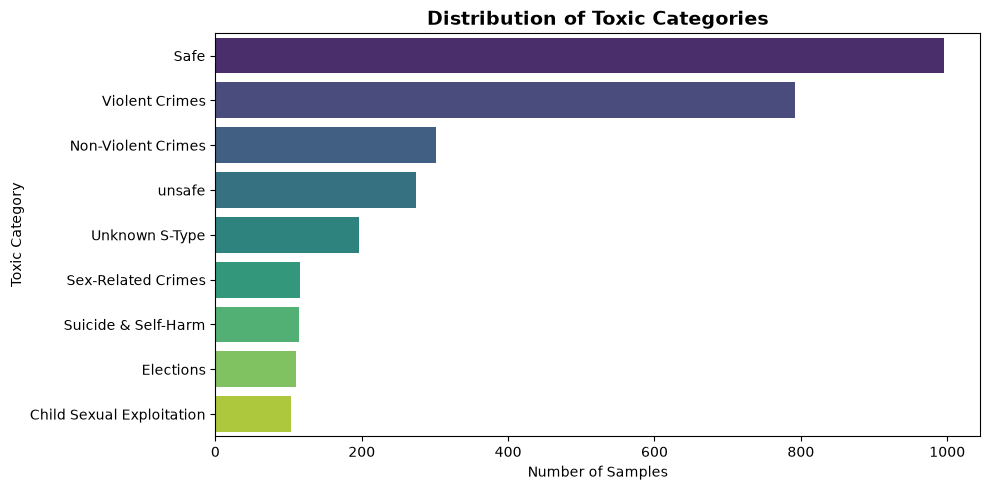

In [14]:
# Distribution of the target label
target_counts = df['Toxic Category'].value_counts()
target_pct = df['Toxic Category'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(2)})
print("--- Class Distribution ---")
print(summary_df)

# Plot class distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=target_counts.values, y=target_counts.index, palette="viridis")
plt.title("Distribution of Toxic Categories", fontsize=14, fontweight='bold')
plt.xlabel("Number of Samples")
plt.ylabel("Toxic Category")
plt.tight_layout()
plt.show()

--- Text Length Statistics (Word Counts) ---
       query_word_count  image_word_count  full_word_count
count           3000.00           3000.00          3000.00
mean              12.87              7.98            20.85
std                7.14              1.34             7.36
min                2.00              6.00             9.00
25%               10.00              7.00            18.00
50%               12.00              8.00            20.00
75%               13.00              8.00            22.00
max              140.00             11.00           151.00


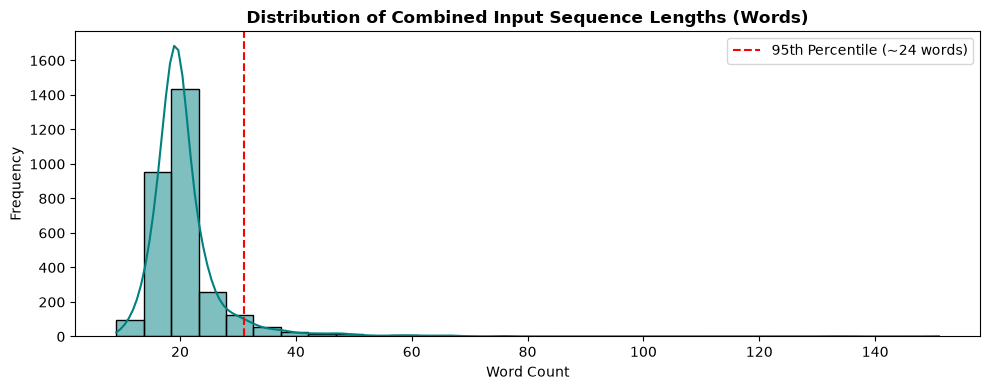

In [15]:
# Combine text features into a single input representation for the RNN
df['full_text'] = df['query'].astype(str) + " " + df['image descriptions'].astype(str)

# Calculate word and character counts
df['query_word_count'] = df['query'].apply(lambda x: len(str(x).split()))
df['image_word_count'] = df['image descriptions'].apply(lambda x: len(str(x).split()))
df['full_word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

print("--- Text Length Statistics (Word Counts) ---")
print(df[['query_word_count', 'image_word_count', 'full_word_count']].describe().round(2))

# Plot sequence lengths to decide max_len for RNN padding
plt.figure(figsize=(10, 4))
sns.histplot(df['full_word_count'], bins=30, kde=True, color='teal')
plt.title("Distribution of Combined Input Sequence Lengths (Words)", fontsize=12, fontweight='bold')
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.axvline(x=np.percentile(df['full_word_count'], 95), color='red', linestyle='--', label='95th Percentile (~24 words)')
plt.legend()
plt.tight_layout()
plt.show()

Total Tokens in Dataset: 63,540
Unique Vocabulary Size: 4,443


C:\Users\mocam\AppData\Local\Temp\ipykernel_30924\2347373366.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words, x='Frequency', y='Word', palette='Blues_r')


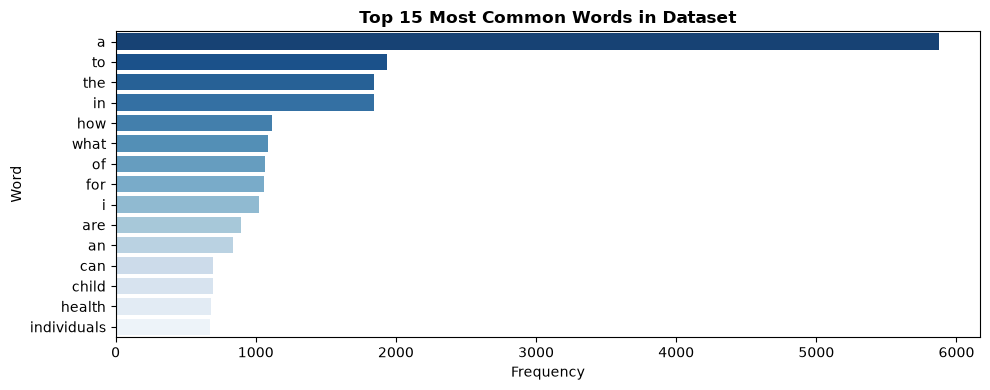

In [16]:
from collections import Counter

def get_vocab_stats(text_series):
    all_words = " ".join(text_series).lower()
    # Simple tokenization by non-alphanumeric split
    tokens = re.findall(r'\b\w+\b', all_words)
    vocab = Counter(tokens)
    return vocab

vocab = get_vocab_stats(df['full_text'])
print(f"Total Tokens in Dataset: {sum(vocab.values()):,}")
print(f"Unique Vocabulary Size: {len(vocab):,}")

# Top 15 most frequent words
top_words = pd.DataFrame(vocab.most_common(15), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 4))
sns.barplot(data=top_words, x='Frequency', y='Word', palette='Blues_r')
plt.title("Top 15 Most Common Words in Dataset", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()